## NDCI Processing

Now that we have explored the focus area and walked through the NDCI analysis workflow in the NDCI_exploration.ipynb, we can scale up the calculations to analyze years worth of data.

**Step 1: import libraries and packages**

In [10]:
import pystac_client
import planetary_computer
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
import odc.stac
import pandas as pd
import time 
import matplotlib.dates as mdates

**Step 2: define access to Microsoft Planetary Computer's Sentinel-2 STAC catalog**

In [4]:
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1", modifier=planetary_computer.sign_inplace)

catalog

<Client id=microsoft-pc>

**Step 3: define get_ndci_timeseries function**

In [5]:
skagit_bbox = (-122.60, 48.18, -122.30, 48.45)
zoom_bbox = (-122.5, 48.24, -122.35, 48.35)

states_gdf = gpd.read_file('http://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_5m.json')
wa_gdf = states_gdf[states_gdf['NAME'] == 'Washington']
wa_gdf_clipped = gpd.clip(wa_gdf, box(*zoom_bbox))

def get_ndci_timeseries(start_date, end_date, region_bbox=skagit_bbox, focus_bbox=zoom_bbox, cloud_thres=0.30):
    """
    This function returns a DataFrame with [time, ndci_median] for the specified date range in YYYY-MM-DD.
    The region and focus area are already specified in the function, but can be changed to explore different 
    areas, minding the possible change of Sentinel-2-12a tiles.
    """
    calc_start = time.time()
    print(f"Calculating NDCI for {start_date} to {end_date}")

    ### Step 1: search and load items from Sentinel-2-12a
    all_items = (list(catalog.search(collections=["sentinel-2-l2a"],
                            bbox=region_bbox,
                            datetime=f"{start_date}/{end_date}",
                            query={"s2:mgrs_tile": {"eq": "10UEU"}}
                           ).item_collection()) +
        list(catalog.search(collections=["sentinel-2-l2a"],
                            bbox=region_bbox,
                            datetime=f"{start_date}/{end_date}",
                            query={"s2:mgrs_tile": {"eq": "10TET"}}
                           ).item_collection())
                )
    
    signed_items = [planetary_computer.sign(item) for item in all_items]
    bands = ["B02", "B03", "B04", "B05", "SCL"]
    s2_ds = odc.stac.load(signed_items, bands=bands, resolution=0.001, chunks={}, 
                          groupby='solar_day', bbox=focus_bbox, crs="EPSG:4326")

    s2_ds_water = s2_ds.rio.clip(wa_gdf_clipped.geometry, wa_gdf_clipped.crs, drop=False, invert=True)

    ### Step 2: filter out imagery with cloud interference
    cloud_scl = [8, 9, 10]
    cloud_fraction = s2_ds_water["SCL"].isin(cloud_scl).mean(dim=["latitude", "longitude"]).compute()
    clean_times = cloud_fraction.time.where(cloud_fraction < cloud_thres, drop=True)
    
    print(f"Timesteps before cloud filtering: {len(s2_ds_water.time.values)}")
    print(f"Timesteps after cloud filtering: {len(clean_times.values)}")

    ### Step 3: calculate NDCI, minding the offset of pre-2022 Sentinel data
    baseline = float(signed_items[0].properties.get("s2:processing_baseline", "0"))
    
    B05 = s2_ds_water["B05"] - (1000 if baseline < 4.0 else 0)
    B04 = s2_ds_water["B04"] - (1000 if baseline < 4.0 else 0)
    
    ndci_da = (B05 - B04) / (B05 + B04)
    water_only = s2_ds_water["SCL"] == 6
    
    # Filter out timesteps with too few water pixels
    water_pixel_counts = water_only.sel(time=clean_times).sum(dim=["latitude", "longitude"]).compute()
    valid_times = water_pixel_counts.time.where(water_pixel_counts > 1000, drop=True)
    print(f"Timesteps after water pixel filtering: {len(valid_times.values)}")
    
    ndci_masked_da = ndci_da.where(water_only).sel(time=valid_times).compute()
    
    ### Step 4: calculate NDCI median per timestep and load into DataFrame
    ndci_median = ndci_masked_da.median(dim=["latitude", "longitude"])
    ndci_median_times = ndci_median.coords["time"].values
    ndci_median_df = pd.DataFrame({
        "time": ndci_median_times,
        "ndci_median": ndci_median.values
    }).dropna(subset=["ndci_median"])  # safety net
    
    calc_time_elapsed = time.time() - calc_start
    print(f"Processing time: {calc_time_elapsed // 60:.0f}m {calc_time_elapsed % 60:.0f}s")

    return ndci_median_df

**Step 4: Analyze away!**

Let's test this function with a short duration to begin:

In [6]:
start = "2022-01-01"
end = "2022-01-31"

get_ndci_timeseries(start, end)

Calculating NDCI for 2022-01-01 to 2022-01-31


/opt/conda/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Timesteps before cloud filtering: 12
Timesteps after cloud filtering: 1
Timesteps after water pixel filtering: 1
Processing time: 0m 5s


,time,ndci_median
0,2022-01-27 19:06:41.024,-0.000539


Great! Now let's calculate the NDCI for all of 2022:

In [7]:
start = "2023-01-01"
end = "2023-12-31"

get_ndci_timeseries(start, end)

Calculating NDCI for 2023-01-01 to 2023-12-31
Timesteps before cloud filtering: 145
Timesteps after cloud filtering: 56
Timesteps after water pixel filtering: 56
Processing time: 1m 18s


,time,ndci_median
0,2023-02-14 19:15:01.024,-0.026361
1,2023-02-24 19:14:01.024,-0.024831
2,2023-02-26 19:03:39.025,-0.021245
3,2023-03-18 19:01:19.024,-0.018166
4,2023-03-21 19:10:59.024,-0.020504
5,2023-03-26 19:10:21.024,-0.019108
6,2023-04-12 18:59:21.024,-0.021185
7,2023-04-27 18:59:19.024,-0.007716
8,2023-05-02 18:59:21.024,-0.018279
9,2023-05-07 18:59:19.024,-0.005354


Now let's do the calculation for our entire desired time period:

In [8]:
yearly_df = []

for year in range(2022, 2026):
    df_year = get_ndci_timeseries(f"{year}-01-01", f"{year}-12-31")
    yearly_df.append(df_year)

ndci_Jan2022_to_Mar2026_df = pd.concat(yearly_df, ignore_index=True).sort_values("time")
ndci_Jan2022_to_Mar2026_df.to_csv("2022to2026_ndci_median.csv", index=False) # ACTUALLY 2018!!
print(ndci_Jan2022_to_Mar2026_df)

Calculating NDCI for 2022-01-01 to 2022-12-31
Timesteps before cloud filtering: 143
Timesteps after cloud filtering: 55
Timesteps after water pixel filtering: 55
Processing time: 0m 58s
Calculating NDCI for 2023-01-01 to 2023-12-31
Timesteps before cloud filtering: 145
Timesteps after cloud filtering: 56
Timesteps after water pixel filtering: 56
Processing time: 0m 60s
Calculating NDCI for 2024-01-01 to 2024-12-31
Timesteps before cloud filtering: 143
Timesteps after cloud filtering: 58
Timesteps after water pixel filtering: 58
Processing time: 0m 49s
Calculating NDCI for 2025-01-01 to 2025-12-31
Timesteps before cloud filtering: 152
Timesteps after cloud filtering: 57
Timesteps after water pixel filtering: 57
Processing time: 0m 53s
                       time  ndci_median
0   2022-01-27 19:06:41.024    -0.000539
1   2022-02-21 19:04:09.024    -0.028642
2   2022-02-24 19:13:49.024    -0.025664
3   2022-03-06 19:12:49.024    -0.028914
4   2022-03-13 19:00:59.024    -0.017544
..        

Let's inspect the data and see how it looks:

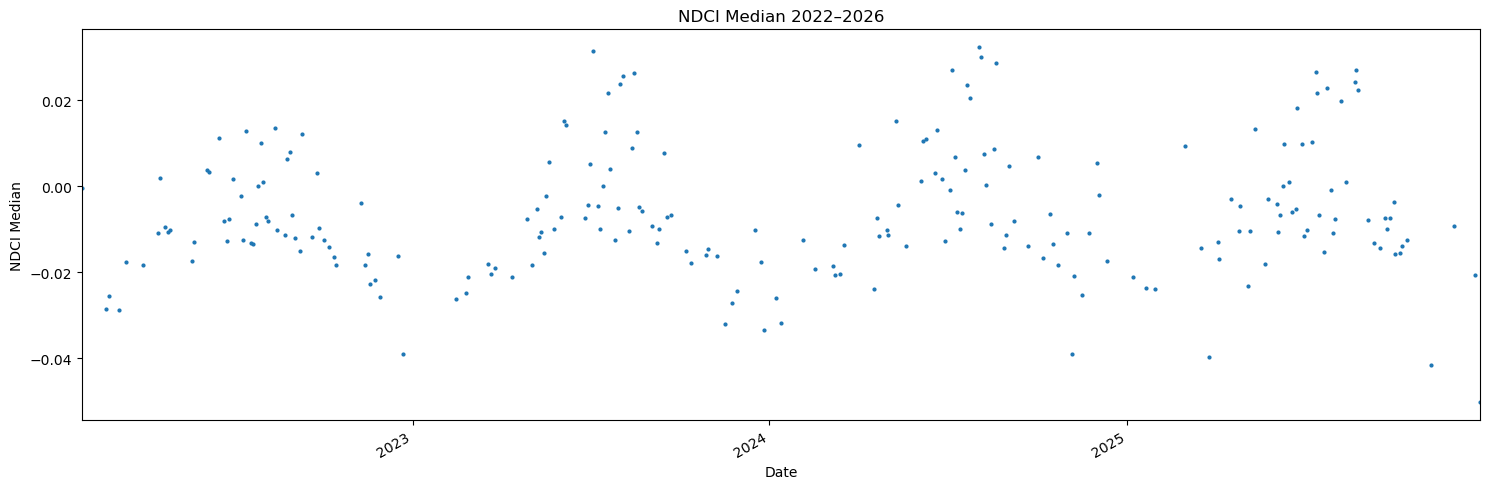

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ndci_Jan2022_to_Mar2026_df['time'], ndci_Jan2022_to_Mar2026_df['ndci_median'], marker='o', markersize=2, linewidth=0.8, ls='')

ax.set_xlim(ndci_Jan2022_to_Mar2026_df['time'].min(), ndci_Jan2022_to_Mar2026_df['time'].max())
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

ax.set_title("NDCI Median 2022–2026")
ax.set_xlabel("Date")
ax.set_ylabel("NDCI Median")
plt.tight_layout()

In [12]:
#[add in some visualizations]

Looks great! That concludes the walkthrough on NDCI processing and visualization.